# Relational-State Benchmark: Model Performance and Error Analysis

This notebook aggregates all model outputs under `evaluation/outputs/`, compares model performance across benchmark tasks, and diagnoses error patterns for the Langtry-inspired relational-state benchmark.

Main questions:

1. How does each model perform on `eval_A`, `eval_B`, `placebo_test`, `ood_social`, and `ood_career`?
2. Where are the largest model-to-model gaps?
3. Which rule confusions, slices, and reasoning patterns explain the mistakes?

In [13]:
from __future__ import annotations

import json
import math
import re
import textwrap
from collections import Counter
from pathlib import Path

import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception as exc:
    plt = None
    HAS_MATPLOTLIB = False
    print(f"matplotlib unavailable; plot cells will be skipped. Reason: {exc}")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

OUTPUT_ROOT = ROOT / "evaluation" / "outputs"
STRUCTURED_ROOT = ROOT / "data" / "structured"

TASK_ORDER = ["eval_A", "eval_B", "placebo_test", "ood_social", "ood_career"]
TASK_LABELS = {
    "eval_A": "Eval-A rule ID",
    "eval_B": "Eval-B comparative statics",
    "placebo_test": "Placebo",
    "ood_social": "OOD social",
    "ood_career": "OOD career",
}

print(f"Project root: {ROOT}")
print(f"Output root: {OUTPUT_ROOT}")

Project root: /hpc2hdd/home/jliu043/relational_state
Output root: /hpc2hdd/home/jliu043/relational_state/evaluation/outputs


In [14]:
def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Bad JSON in {path}:{line_no}") from exc
    return rows


def flatten_prediction(row: dict, model_dir: str, prediction_file: Path) -> dict:
    meta = row.get("meta") or {}
    flat = {
        "model_dir": model_dir,
        "model": row.get("model") or model_dir,
        "task_id": row.get("task_id"),
        "dataset_split": row.get("dataset_split"),
        "gold_letter": row.get("gold_letter"),
        "parsed_letter": row.get("parsed_letter"),
        "parsed_rule_id": row.get("parsed_rule_id"),
        "is_correct": bool(row.get("is_correct")),
        "raw_response": row.get("raw_response") or "",
        "prompt": row.get("prompt") or "",
        "prediction_file": str(prediction_file.relative_to(ROOT)),
    }
    for key, value in meta.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            flat[key] = value
        elif key == "letter_to_rule" and isinstance(value, dict):
            flat[key] = value
            flat["gold_rule_id"] = flat.get("gold_rule_id") or value.get(flat["gold_letter"])
            flat["parsed_rule_id"] = flat.get("parsed_rule_id") or value.get(flat["parsed_letter"])
        else:
            flat[key] = json.dumps(value, ensure_ascii=False)
    return flat


prediction_files = sorted(OUTPUT_ROOT.glob("*/*_predictions.jsonl"))
if not prediction_files:
    raise FileNotFoundError(f"No prediction files found under {OUTPUT_ROOT}")

all_rows = []
for path in prediction_files:
    model_dir = path.parent.name
    for row in read_jsonl(path):
        all_rows.append(flatten_prediction(row, model_dir, path))

pred = pd.DataFrame(all_rows)
# Normalize model directory labels for cleaner cross-run comparison tables.
pred["model_dir"] = pred["model_dir"].replace({"gpt-4": "gpt4"})
pred["dataset_split"] = pd.Categorical(pred["dataset_split"], TASK_ORDER, ordered=True)
pred["correct_int"] = pred["is_correct"].astype(int)
pred["is_parsed"] = pred["parsed_letter"].notna()

print(f"Loaded {len(pred):,} predictions from {len(prediction_files)} files.")
print("Models:", ", ".join(sorted(pred["model_dir"].unique())))
display(pred.groupby(["model_dir", "dataset_split"], observed=True).size().unstack(fill_value=0).loc[:, TASK_ORDER])

Loaded 17,240 predictions from 25 files.


dataset_split,eval_A,eval_B,placebo_test,ood_social,ood_career
model_dir,,,,,
DeepSeek-R1-671B,1512,280,504,576,576
Qwen,1512,280,504,576,576
ollama-llama3-1-latest,1512,280,504,576,576
ollama-llama3-8b,1512,280,504,576,576
ollama-qwen2-7b,1512,280,504,576,576


## 1. Overall Task Performance

The first table is the main leaderboard: rows are model output directories and columns are benchmark splits. The second table adds counts so incomplete runs are visible.

In [15]:
perf = (
    pred.groupby(["model_dir", "dataset_split"], observed=True)
    .agg(total=("task_id", "count"), correct=("correct_int", "sum"), accuracy=("correct_int", "mean"), parse_rate=("is_parsed", "mean"))
    .reset_index()
)
perf["accuracy_pct"] = 100 * perf["accuracy"]
perf["parse_rate_pct"] = 100 * perf["parse_rate"]

acc_table = (
    perf.pivot(index="model_dir", columns="dataset_split", values="accuracy_pct")
    .reindex(columns=TASK_ORDER)
    .sort_values(by=TASK_ORDER, ascending=False, na_position="last")
)
count_table = perf.pivot(index="model_dir", columns="dataset_split", values="total").reindex(columns=TASK_ORDER)

print("Accuracy (%):")
display(acc_table.style.format("{:.1f}").background_gradient(cmap="Blues", axis=None))

print("Counts:")
display(count_table.fillna(0).astype(int))

Accuracy (%):


dataset_split,eval_A,eval_B,placebo_test,ood_social,ood_career
model_dir,,,,,
ollama-qwen2-7b,46.6,56.4,91.7,59.2,47.6
ollama-llama3-1-latest,41.7,61.8,75.2,62.0,50.3
ollama-llama3-8b,40.3,58.2,79.4,59.7,51.7
Qwen,33.9,70.0,59.7,66.0,49.5
DeepSeek-R1-671B,23.4,59.6,30.0,56.9,45.8


Counts:


dataset_split,eval_A,eval_B,placebo_test,ood_social,ood_career
model_dir,,,,,
DeepSeek-R1-671B,1512,280,504,576,576
Qwen,1512,280,504,576,576
ollama-llama3-1-latest,1512,280,504,576,576
ollama-llama3-8b,1512,280,504,576,576
ollama-qwen2-7b,1512,280,504,576,576


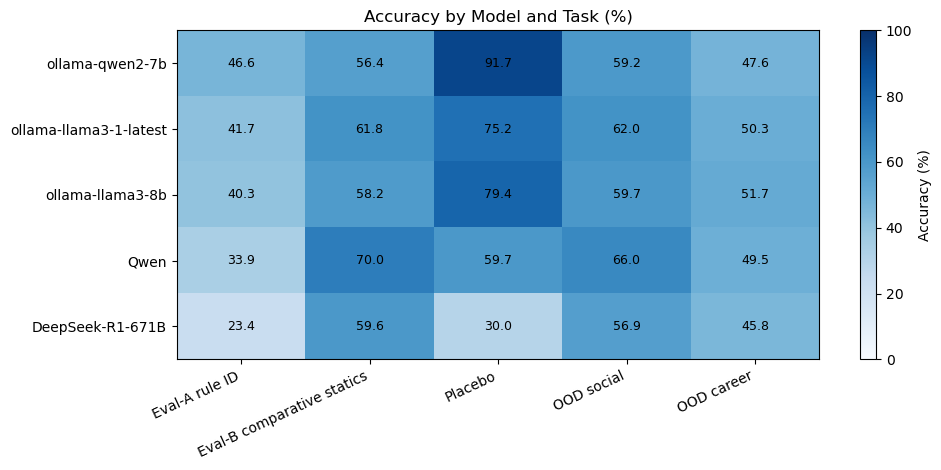

In [16]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(10, 4.8))
    plot_data = acc_table.reindex(columns=TASK_ORDER)
    im = ax.imshow(plot_data.values, aspect="auto", cmap="Blues", vmin=0, vmax=100)
    ax.set_xticks(range(len(plot_data.columns)))
    ax.set_xticklabels([TASK_LABELS.get(c, c) for c in plot_data.columns], rotation=25, ha="right")
    ax.set_yticks(range(len(plot_data.index)))
    ax.set_yticklabels(plot_data.index)
    for i in range(plot_data.shape[0]):
        for j in range(plot_data.shape[1]):
            value = plot_data.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="black", fontsize=9)
    ax.set_title("Accuracy by Model and Task (%)")
    fig.colorbar(im, ax=ax, label="Accuracy (%)")
    plt.tight_layout()
else:
    print("Skipping heatmap because matplotlib is unavailable in this environment.")

## 2. Model Differences

These diagnostics highlight which model is best on each task and where models disagree most on the same items.

In [17]:
task_gap = (
    perf.groupby("dataset_split", observed=True)
    .agg(best_acc=("accuracy_pct", "max"), worst_acc=("accuracy_pct", "min"), mean_acc=("accuracy_pct", "mean"), n_models=("model_dir", "nunique"))
    .reset_index()
)
task_gap["spread"] = task_gap["best_acc"] - task_gap["worst_acc"]

def best_models_for_task(split: str) -> str:
    sub = perf[perf["dataset_split"].astype(str) == split]
    if sub.empty:
        return ""
    best = sub["accuracy_pct"].max()
    return ", ".join(sub.loc[sub["accuracy_pct"].eq(best), "model_dir"].sort_values())

task_gap["best_model"] = task_gap["dataset_split"].astype(str).map(best_models_for_task)
display(task_gap.sort_values("spread", ascending=False).style.format({"best_acc": "{:.1f}", "worst_acc": "{:.1f}", "mean_acc": "{:.1f}", "spread": "{:.1f}"}))

# Item-level disagreement: how often models split on the same task_id.
item_agree = (
    pred.groupby(["dataset_split", "task_id"], observed=True)
    .agg(n_models=("model_dir", "nunique"), n_correct=("correct_int", "sum"), parsed_letters=("parsed_letter", lambda s: tuple(sorted(set(x for x in s if pd.notna(x))))))
    .reset_index()
)
item_agree["correct_rate_across_models"] = item_agree["n_correct"] / item_agree["n_models"]
item_agree["is_full_disagreement"] = item_agree["correct_rate_across_models"].between(0.01, 0.99)

disagreement_summary = (
    item_agree.groupby("dataset_split", observed=True)
    .agg(items=("task_id", "count"), mean_cross_model_correct=("correct_rate_across_models", "mean"), disagreement_items=("is_full_disagreement", "sum"))
    .reset_index()
)
disagreement_summary["disagreement_rate"] = disagreement_summary["disagreement_items"] / disagreement_summary["items"]
display(disagreement_summary.style.format({"mean_cross_model_correct": "{:.3f}", "disagreement_rate": "{:.1%}"}))

,dataset_split,best_acc,worst_acc,mean_acc,n_models,spread,best_model
2,placebo_test,91.7,30.0,67.2,5,61.7,ollama-qwen2-7b
0,eval_A,46.6,23.4,37.2,5,23.2,ollama-qwen2-7b
1,eval_B,70.0,56.4,61.2,5,13.6,Qwen
3,ood_social,66.0,56.9,60.8,5,9.0,Qwen
4,ood_career,51.7,45.8,49.0,5,5.9,ollama-llama3-8b


,dataset_split,items,mean_cross_model_correct,disagreement_items,disagreement_rate
0,eval_A,1512,0.372,1256,83.1%
1,eval_B,280,0.612,227,81.1%
2,placebo_test,504,0.672,423,83.9%
3,ood_social,576,0.608,370,64.2%
4,ood_career,576,0.490,158,27.4%


## 3. Slice Analysis

The benchmark is designed around interpretable slices: `alpha_bucket`, `dispersion_bucket`, `skew_bucket`, held-out cells, perturbation type, OOD match distance, and career `alpha_2i_bucket`. Low-performing slices usually reveal what kind of relational reasoning the model misses.

In [18]:
SLICE_FIELDS = [
    "domain_key",
    "scene_id",
    "alpha_bucket",
    "dispersion_bucket",
    "skew_bucket",
    "is_held_out_cell",
    "cell_id",
    "perturbation",
    "match_distance_bucket",
    "alpha_2i_bucket",
    "gold_rule_id",
    "parsed_rule_id",
    "gold_firm",
]


def slice_table(df: pd.DataFrame, field: str, min_total: int = 20) -> pd.DataFrame:
    if field not in df.columns:
        return pd.DataFrame()
    out = (
        df.dropna(subset=[field])
        .groupby(["model_dir", "dataset_split", field], observed=True)
        .agg(total=("task_id", "count"), correct=("correct_int", "sum"), accuracy=("correct_int", "mean"))
        .reset_index()
    )
    out = out[out["total"] >= min_total].copy()
    out["accuracy_pct"] = 100 * out["accuracy"]
    return out.sort_values(["dataset_split", "accuracy_pct", "total"], ascending=[True, True, False])

for field in ["alpha_bucket", "dispersion_bucket", "skew_bucket", "is_held_out_cell", "perturbation", "match_distance_bucket", "alpha_2i_bucket", "domain_key"]:
    tbl = slice_table(pred, field)
    if not tbl.empty:
        print(f"\nLowest slices by {field}")
        display(tbl.head(15).style.format({"accuracy": "{:.3f}", "accuracy_pct": "{:.1f}"}))


Lowest slices by alpha_bucket


,model_dir,dataset_split,alpha_bucket,total,correct,accuracy,accuracy_pct
0,DeepSeek-R1-671B,eval_A,high,504,97,0.192,19.2
2,DeepSeek-R1-671B,eval_A,mid,504,118,0.234,23.4
1,DeepSeek-R1-671B,eval_A,low,504,139,0.276,27.6
3,Qwen,eval_A,high,504,141,0.280,28.0
5,Qwen,eval_A,mid,504,166,0.329,32.9
11,ollama-llama3-8b,eval_A,mid,504,188,0.373,37.3
9,ollama-llama3-8b,eval_A,high,504,191,0.379,37.9
6,ollama-llama3-1-latest,eval_A,high,504,197,0.391,39.1
4,Qwen,eval_A,low,504,205,0.407,40.7
8,ollama-llama3-1-latest,eval_A,mid,504,205,0.407,40.7



Lowest slices by dispersion_bucket


,model_dir,dataset_split,dispersion_bucket,total,correct,accuracy,accuracy_pct
0,DeepSeek-R1-671B,eval_A,high,504,113,0.224,22.4
1,DeepSeek-R1-671B,eval_A,low,504,119,0.236,23.6
2,DeepSeek-R1-671B,eval_A,mid,504,122,0.242,24.2
3,Qwen,eval_A,high,504,151,0.300,30.0
4,Qwen,eval_A,low,504,170,0.337,33.7
5,Qwen,eval_A,mid,504,191,0.379,37.9
10,ollama-llama3-8b,eval_A,low,504,194,0.385,38.5
7,ollama-llama3-1-latest,eval_A,low,504,206,0.409,40.9
11,ollama-llama3-8b,eval_A,mid,504,207,0.411,41.1
9,ollama-llama3-8b,eval_A,high,504,209,0.415,41.5



Lowest slices by skew_bucket


...

,model_dir,dataset_split,match_distance_bucket,total,correct,accuracy,accuracy_pct
2,DeepSeek-R1-671B,ood_social,mid,216,110,0.509,50.9
14,ollama-qwen2-7b,ood_social,mid,216,112,0.519,51.9
8,ollama-llama3-1-latest,ood_social,mid,216,113,0.523,52.3
11,ollama-llama3-8b,ood_social,mid,216,114,0.528,52.8
0,DeepSeek-R1-671B,ood_social,close,216,126,0.583,58.3
9,ollama-llama3-8b,ood_social,close,216,129,0.597,59.7
5,Qwen,ood_social,mid,216,130,0.602,60.2
12,ollama-qwen2-7b,ood_social,close,216,130,0.602,60.2
1,DeepSeek-R1-671B,ood_social,far,144,92,0.639,63.9
6,ollama-llama3-1-latest,ood_social,close,216,140,0.648,64.8



Lowest slices by alpha_2i_bucket


,model_dir,dataset_split,alpha_2i_bucket,total,correct,accuracy,accuracy_pct
1,DeepSeek-R1-671B,ood_career,low,192,84,0.438,43.8
2,DeepSeek-R1-671B,ood_career,mid,192,88,0.458,45.8
14,ollama-qwen2-7b,ood_career,mid,192,89,0.464,46.4
4,Qwen,ood_career,low,192,91,0.474,47.4
13,ollama-qwen2-7b,ood_career,low,192,91,0.474,47.4
0,DeepSeek-R1-671B,ood_career,high,192,92,0.479,47.9
7,ollama-llama3-1-latest,ood_career,low,192,92,0.479,47.9
12,ollama-qwen2-7b,ood_career,high,192,94,0.490,49.0
5,Qwen,ood_career,mid,192,95,0.495,49.5
10,ollama-llama3-8b,ood_career,low,192,97,0.505,50.5



Lowest slices by domain_key


,model_dir,dataset_split,domain_key,total,correct,accuracy,accuracy_pct
1,DeepSeek-R1-671B,eval_A,domain3_effort_and_human_capital,648,147,0.227,22.7
0,DeepSeek-R1-671B,eval_A,domain1_positional_consumption,864,207,0.240,24.0
8,Qwen,eval_A,domain3_effort_and_human_capital,648,212,0.327,32.7
7,Qwen,eval_A,domain1_positional_consumption,864,300,0.347,34.7
22,ollama-llama3-8b,eval_A,domain3_effort_and_human_capital,648,254,0.392,39.2
15,ollama-llama3-1-latest,eval_A,domain3_effort_and_human_capital,648,255,0.394,39.4
21,ollama-llama3-8b,eval_A,domain1_positional_consumption,864,356,0.412,41.2
14,ollama-llama3-1-latest,eval_A,domain1_positional_consumption,864,376,0.435,43.5
29,ollama-qwen2-7b,eval_A,domain3_effort_and_human_capital,648,284,0.438,43.8
28,ollama-qwen2-7b,eval_A,domain1_positional_consumption,864,421,0.487,48.7


## 4. Error Cause Diagnostics

The following cells turn wrong predictions into interpretable failure modes. The labels are heuristic, but they are anchored in the benchmark design: shortcut rule confusion for `eval_A` / `placebo_test`, perturbation blindness for `eval_B`, and absolute-pay versus relative-status tradeoffs for `ood_career`.

In [19]:
RULE_DESCRIPTIONS = {
    "A_peer_weighted": "Langtry gold: baseline + alpha * closeness-weighted peer reference",
    "B_top_anchor": "Shortcut: closest/top peer stacked on baseline",
    "C_uniform_avg": "Shortcut: flat peer average instead of g_ij weights",
    "D_pure_private": "Private baseline only; should dominate placebo",
    "E_closest_mimicry": "Shortcut: clone closest peer directly",
    "F_median_anchor": "Shortcut: median peer anchor",
    "G_counter_conformist": "Counter-conformist distractor",
    "H_equal_mix": "Equal mix of private baseline and social aggregate",
}

rule_tasks = pred[pred["dataset_split"].astype(str).isin(["eval_A", "placebo_test"])].copy()
wrong_rule = rule_tasks[~rule_tasks["is_correct"]].copy()

confusion = (
    wrong_rule.groupby(["model_dir", "dataset_split", "gold_rule_id", "parsed_rule_id"], observed=True)
    .size()
    .reset_index(name="n")
)
confusion["share_of_task_errors"] = confusion["n"] / confusion.groupby(["model_dir", "dataset_split"], observed=True)["n"].transform("sum")
confusion["parsed_rule_meaning"] = confusion["parsed_rule_id"].map(RULE_DESCRIPTIONS)

print("Most common wrong-rule confusions:")
display(confusion.sort_values(["dataset_split", "model_dir", "n"], ascending=[True, True, False]).head(40).style.format({"share_of_task_errors": "{:.1%}"}))

# Compact confusion matrices per model/task.
for split in ["eval_A", "placebo_test"]:
    print(f"\nParsed rule distribution on wrong {split} items")
    matrix = (
        wrong_rule[wrong_rule["dataset_split"].astype(str).eq(split)]
        .pivot_table(index="model_dir", columns="parsed_rule_id", values="task_id", aggfunc="count", fill_value=0, observed=True)
    )
    if not matrix.empty:
        display(matrix)

Most common wrong-rule confusions:


,model_dir,dataset_split,gold_rule_id,parsed_rule_id,n,share_of_task_errors,parsed_rule_meaning
1,DeepSeek-R1-671B,eval_A,A_peer_weighted,C_uniform_avg,245,21.2%,Shortcut: flat peer average instead of g_ij weights
4,DeepSeek-R1-671B,eval_A,A_peer_weighted,F_median_anchor,213,18.4%,Shortcut: median peer anchor
6,DeepSeek-R1-671B,eval_A,A_peer_weighted,H_equal_mix,198,17.1%,Equal mix of private baseline and social aggregate
0,DeepSeek-R1-671B,eval_A,A_peer_weighted,B_top_anchor,184,15.9%,Shortcut: closest/top peer stacked on baseline
3,DeepSeek-R1-671B,eval_A,A_peer_weighted,E_closest_mimicry,125,10.8%,Shortcut: clone closest peer directly
5,DeepSeek-R1-671B,eval_A,A_peer_weighted,G_counter_conformist,96,8.3%,Counter-conformist distractor
2,DeepSeek-R1-671B,eval_A,A_peer_weighted,D_pure_private,95,8.2%,Private baseline only; should dominate placebo
15,Qwen,eval_A,A_peer_weighted,C_uniform_avg,205,20.6%,Shortcut: flat peer average instead of g_ij weights
14,Qwen,eval_A,A_peer_weighted,B_top_anchor,176,17.7%,Shortcut: closest/top peer stacked on baseline
18,Qwen,eval_A,A_peer_weighted,F_median_anchor,174,17.5%,Shortcut: median peer anchor



Parsed rule distribution on wrong eval_A items


parsed_rule_id,B_top_anchor,C_uniform_avg,D_pure_private,E_closest_mimicry,F_median_anchor,G_counter_conformist,H_equal_mix
model_dir,,,,,,,
DeepSeek-R1-671B,184,245,95,125,213,96,198
Qwen,176,205,103,146,174,34,155
ollama-llama3-1-latest,153,67,239,141,99,69,113
ollama-llama3-8b,136,58,252,157,118,55,126
ollama-qwen2-7b,131,77,207,143,123,13,113



Parsed rule distribution on wrong placebo_test items


parsed_rule_id,A_peer_weighted,B_top_anchor,C_uniform_avg,E_closest_mimicry,F_median_anchor,G_counter_conformist,H_equal_mix
model_dir,,,,,,,
DeepSeek-R1-671B,42,50,78,32,53,28,62
Qwen,27,39,32,14,53,9,26
ollama-llama3-1-latest,36,21,6,12,21,8,21
ollama-llama3-8b,25,15,11,16,14,10,13
ollama-qwen2-7b,14,5,4,2,10,1,6


,model_dir,perturbation,total,correct,accuracy,avg_gap_over_F,accuracy_pct
4,DeepSeek-R1-671B,top_weight_up,56,26,0.464286,0.191,46.4
0,DeepSeek-R1-671B,F_up,56,29,0.517857,0.398,51.8
1,DeepSeek-R1-671B,alpha_i_up,56,29,0.517857,1.169,51.8
2,DeepSeek-R1-671B,peer_action_up,56,41,0.732143,0.394,73.2
3,DeepSeek-R1-671B,ref_sum_up,56,42,0.750000,0.393,75.0
5,Qwen,F_up,56,30,0.535714,0.398,53.6
9,Qwen,top_weight_up,56,31,0.553571,0.191,55.4
6,Qwen,alpha_i_up,56,32,0.571429,1.169,57.1
7,Qwen,peer_action_up,56,51,0.910714,0.394,91.1
8,Qwen,ref_sum_up,56,52,0.928571,0.393,92.9


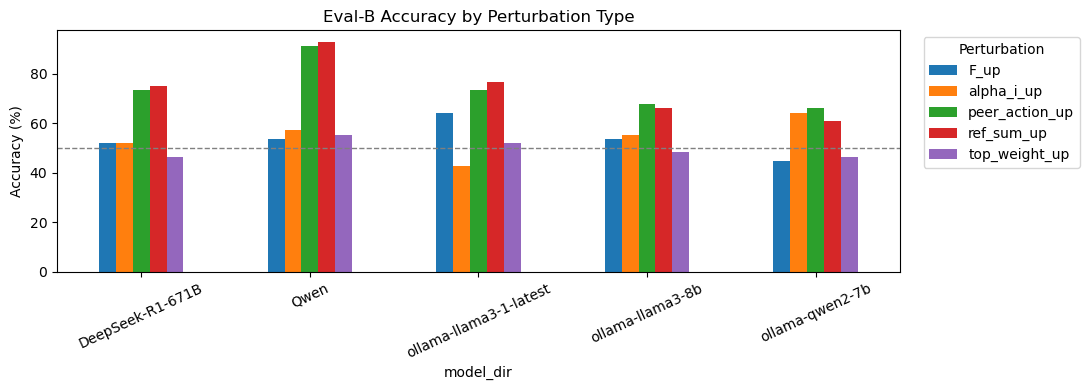

In [20]:
eval_b = pred[pred["dataset_split"].astype(str).eq("eval_B")].copy()
if not eval_b.empty:
    b_by_pert = (
        eval_b.groupby(["model_dir", "perturbation"], observed=True)
        .agg(total=("task_id", "count"), correct=("correct_int", "sum"), accuracy=("correct_int", "mean"), avg_gap_over_F=("gap_over_F", "mean"))
        .reset_index()
    )
    b_by_pert["accuracy_pct"] = 100 * b_by_pert["accuracy"]
    display(b_by_pert.sort_values(["model_dir", "accuracy_pct"]).style.format({"accuracy_pct": "{:.1f}", "avg_gap_over_F": "{:.3f}"}))

    if HAS_MATPLOTLIB:
        pivot = b_by_pert.pivot(index="model_dir", columns="perturbation", values="accuracy_pct")
        ax = pivot.plot(kind="bar", figsize=(11, 4), rot=25)
        ax.set_ylabel("Accuracy (%)")
        ax.set_title("Eval-B Accuracy by Perturbation Type")
        ax.axhline(50, color="gray", linestyle="--", linewidth=1)
        plt.legend(title="Perturbation", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
    else:
        print("Skipping Eval-B bar plot because matplotlib is unavailable in this environment.")
else:
    print("No Eval-B rows found.")

In [21]:
def infer_error_cause(row: pd.Series) -> str:
    split = str(row.get("dataset_split"))
    parsed = row.get("parsed_rule_id")
    gold = row.get("gold_rule_id")
    raw = (row.get("raw_response") or "").lower()
    prompt = (row.get("prompt") or "").lower()

    if row.get("is_correct"):
        return "correct"
    if not row.get("is_parsed", True):
        return "format / parse failure"

    if split == "eval_A":
        if parsed == "C_uniform_avg":
            return "uses flat average instead of closeness weights"
        if parsed == "B_top_anchor":
            return "over-anchors on closest/highest peer"
        if parsed == "E_closest_mimicry":
            return "copies closest peer directly"
        if parsed == "F_median_anchor":
            return "uses median/central peer shortcut"
        if parsed == "D_pure_private":
            return "ignores social reference in positional task"
        return f"other rule confusion: {gold} -> {parsed}"

    if split == "placebo_test":
        if parsed == "A_peer_weighted":
            return "hallucinates peer-weighted pull in placebo"
        if parsed in {"B_top_anchor", "C_uniform_avg", "E_closest_mimicry", "F_median_anchor"}:
            return "uses social shortcut although gold is private baseline"
        return f"other placebo confusion: {gold} -> {parsed}"

    if split == "eval_B":
        pert = row.get("perturbation")
        if pert == "alpha_i_up":
            return "misses social-sensitivity alpha change"
        if pert == "F_up":
            return "misses private-baseline F change"
        if pert == "ref_sum_up":
            return "misses weighted reference aggregate change"
        if pert == "peer_action_up":
            return "misses peer-action level change"
        if pert == "top_weight_up":
            return "misreads closeness-weight redistribution"
        return "comparative-static direction error"

    if split == "ood_social":
        return "misses b/c matching stability criterion"

    if split == "ood_career":
        if "top of" in raw or "status" in raw or "relative" in raw:
            return "overweights relative status versus Langtry threshold"
        if "salary" in raw or "paycheck" in raw or "higher" in raw:
            return "overweights absolute salary / prestige"
        return "career threshold tradeoff error"

    return "other"

pred["error_cause"] = pred.apply(infer_error_cause, axis=1)
wrong = pred[~pred["is_correct"]].copy()

cause_summary = (
    wrong.groupby(["dataset_split", "model_dir", "error_cause"], observed=True)
    .size()
    .reset_index(name="n")
)
cause_summary["share_of_model_task_errors"] = cause_summary["n"] / cause_summary.groupby(["dataset_split", "model_dir"], observed=True)["n"].transform("sum")

display(cause_summary.sort_values(["dataset_split", "model_dir", "n"], ascending=[True, True, False]).style.format({"share_of_model_task_errors": "{:.1%}"}))

,dataset_split,model_dir,error_cause,n,share_of_model_task_errors
6,eval_A,DeepSeek-R1-671B,uses flat average instead of closeness weights,245,21.2%
7,eval_A,DeepSeek-R1-671B,uses median/central peer shortcut,213,18.4%
4,eval_A,DeepSeek-R1-671B,other rule confusion: A_peer_weighted -> H_equal_mix,198,17.1%
5,eval_A,DeepSeek-R1-671B,over-anchors on closest/highest peer,184,15.9%
0,eval_A,DeepSeek-R1-671B,copies closest peer directly,125,10.8%
3,eval_A,DeepSeek-R1-671B,other rule confusion: A_peer_weighted -> G_counter_conformist,96,8.3%
2,eval_A,DeepSeek-R1-671B,ignores social reference in positional task,95,8.2%
1,eval_A,DeepSeek-R1-671B,format / parse failure,2,0.2%
14,eval_A,Qwen,uses flat average instead of closeness weights,205,20.5%
13,eval_A,Qwen,over-anchors on closest/highest peer,176,17.6%


## 5. Prompt and Reasoning Clues

These cells inspect textual clues in the model responses. They are useful for distinguishing arithmetic errors, shortcut selection, and instruction-following failures.

In [22]:
TEXT_MARKERS = {
    "mentions_average": r"average|mean|flat|uniform|democratic",
    "mentions_closest": r"closest|nearest|intimate|close friend|tight friend",
    "mentions_weight": r"weight|weighted|closeness|proportion",
    "mentions_baseline": r"baseline|private floor|comfort zone|what i'd do|natural",
    "mentions_median": r"median|middle|halfway",
    "mentions_status": r"status|relative|top of|bottom of|overshadowed|standout",
    "mentions_salary": r"salary|pay|paycheck|higher wage|bigger paycheck",
    "overlong_response": None,
}

for col, pattern in TEXT_MARKERS.items():
    if col == "overlong_response":
        pred[col] = pred["raw_response"].str.len().fillna(0).gt(1500)
    else:
        pred[col] = pred["raw_response"].str.lower().str.contains(pattern, regex=True, na=False)

marker_cols = list(TEXT_MARKERS)
marker_summary = []
for marker in marker_cols:
    tmp = (
        pred.groupby(["dataset_split", "model_dir", marker], observed=True)
        .agg(total=("task_id", "count"), accuracy=("correct_int", "mean"))
        .reset_index()
    )
    tmp = tmp[tmp[marker]].copy()
    tmp["marker"] = marker
    marker_summary.append(tmp[["dataset_split", "model_dir", "marker", "total", "accuracy"]])
marker_summary = pd.concat(marker_summary, ignore_index=True)
marker_summary["accuracy_pct"] = 100 * marker_summary["accuracy"]

display(marker_summary.sort_values(["dataset_split", "model_dir", "accuracy_pct"]).style.format({"accuracy_pct": "{:.1f}"}))

,dataset_split,model_dir,marker,total,accuracy,accuracy_pct
89,eval_A,DeepSeek-R1-671B,mentions_median,630,0.203175,20.3
108,eval_A,DeepSeek-R1-671B,mentions_status,505,0.207921,20.8
70,eval_A,DeepSeek-R1-671B,mentions_baseline,1494,0.231593,23.2
155,eval_A,DeepSeek-R1-671B,overlong_response,1499,0.232155,23.2
0,eval_A,DeepSeek-R1-671B,mentions_average,1497,0.232465,23.2
133,eval_A,DeepSeek-R1-671B,mentions_salary,64,0.234375,23.4
25,eval_A,DeepSeek-R1-671B,mentions_closest,1248,0.235577,23.6
46,eval_A,DeepSeek-R1-671B,mentions_weight,1432,0.241620,24.2
109,eval_A,Qwen,mentions_status,400,0.172500,17.2
134,eval_A,Qwen,mentions_salary,24,0.208333,20.8


## 6. Representative Wrong Items

Use these examples to read concrete failures. The table intentionally keeps the prompt and response short; adjust `MODEL_TO_INSPECT`, `SPLIT_TO_INSPECT`, and `CAUSE_TO_INSPECT` to drill down.

In [23]:
MODEL_TO_INSPECT = None  # e.g. "DeepSeek-R1-671B"; None = all models
SPLIT_TO_INSPECT = "eval_A"  # choose from TASK_ORDER or set None
CAUSE_TO_INSPECT = None  # e.g. "uses flat average instead of closeness weights"
N_EXAMPLES = 12

examples = wrong.copy()
if MODEL_TO_INSPECT:
    examples = examples[examples["model_dir"].eq(MODEL_TO_INSPECT)]
if SPLIT_TO_INSPECT:
    examples = examples[examples["dataset_split"].astype(str).eq(SPLIT_TO_INSPECT)]
if CAUSE_TO_INSPECT:
    examples = examples[examples["error_cause"].eq(CAUSE_TO_INSPECT)]

examples = examples.sort_values(["model_dir", "dataset_split", "error_cause", "task_id"]).head(N_EXAMPLES).copy()
examples["prompt_excerpt"] = examples["prompt"].str.replace("\n", " ").str.slice(0, 360)
examples["response_excerpt"] = examples["raw_response"].str.replace("\n", " ").str.slice(0, 420)

cols = [
    "model_dir", "dataset_split", "task_id", "error_cause",
    "gold_letter", "parsed_letter", "gold_rule_id", "parsed_rule_id",
    "alpha_bucket", "dispersion_bucket", "skew_bucket", "perturbation", "alpha_2i_bucket",
    "prompt_excerpt", "response_excerpt",
]
cols = [c for c in cols if c in examples.columns]
display(examples[cols])

,model_dir,dataset_split,task_id,error_cause,gold_letter,parsed_letter,gold_rule_id,parsed_rule_id,alpha_bucket,dispersion_bucket,skew_bucket,perturbation,alpha_2i_bucket,prompt_excerpt,response_excerpt
1503,DeepSeek-R1-671B,eval_A,evalA__d1_cele_02__alpha_high__disp_low__skew_mid__03,copies closest peer directly,D,A,A_peer_weighted,E_closest_mimicry,high,low,mid,NaN,NaN,Scenario: Our neighborhood parent group chat lit up with first-birthday plans today. Instagram still shows last year's balloon arches and custom smash cakes from Chloe's twins ...,"First, I need to understand the scenario. The protagonist is in a parent group chat discussing first-birthday party budgets. They see high budgets from other parents: Chloe spe..."
23,DeepSeek-R1-671B,eval_A,evalA__d1_cele_02__alpha_low__disp_high__skew_low__00,copies closest peer directly,A,C,A_peer_weighted,E_closest_mimicry,low,high,low,NaN,NaN,Scenario: Our young-parent group chat has been flooded with first-birthday party plans ever since Lena posted her son's jungle-themed bash on Instagram. I'd penciled in $700 fo...,"First, I need to understand the scenario. The protagonist is planning their child's first birthday party and had a baseline budget of $700 for a simple celebration with close f..."
1064,DeepSeek-R1-671B,eval_A,evalA__d1_cele_02__alpha_low__disp_low__skew_high__01,copies closest peer directly,B,A,A_peer_weighted,E_closest_mimicry,low,low,high,NaN,NaN,Scenario: Planning my toddler's first birthday in our neighborhood parent group chat feels like walking into a glitter bomb. My quiet dream was backyard cupcakes and a bubble m...,"First, I need to understand the scenario. The protagonist is planning their toddler's first birthday and has a quiet dream of a simple backyard party costing $1,570. But in a p..."
762,DeepSeek-R1-671B,eval_A,evalA__d1_cele_02__alpha_mid__disp_low__skew_high__01,copies closest peer directly,B,A,A_peer_weighted,E_closest_mimicry,mid,low,high,NaN,NaN,"Scenario: Our young-parent group chat lit up with first-birthday plans, Instagram reminders flashing of last year's designer-themed bashes. I'd budgeted $1,880 for pizza and a ...","First, I need to understand the scenario. The protagonist is in a young-parent group chat where others are sharing expensive first-birthday party plans: Chloe at $6,978, Noah a..."
1266,DeepSeek-R1-671B,eval_A,evalA__d1_dining_03__alpha_high__disp_high__skew_low__01,copies closest peer directly,B,A,A_peer_weighted,E_closest_mimicry,high,high,low,NaN,NaN,"Scenario: After landing our big promotions, Leo—my closest work buddy and weekly hiking partner—pushed our crew to book a twelve-course tasting night. 'We earned this!' he decl...","First, I need to understand the scenario. The protagonist is deciding on a monthly restaurant spend for a group event. Leo, who is a close friend and work buddy, is pushing for..."
1260,DeepSeek-R1-671B,eval_A,evalA__d1_dining_03__alpha_low__disp_high__skew_low__00,copies closest peer directly,A,D,A_peer_weighted,E_closest_mimicry,low,high,low,NaN,NaN,"Scenario: After our consulting promotions, the crew dove into group chat chaos hunting for a twelve-course tasting spot. My roommate Leo—we've been tight since training—raved a...","First, I need to understand the scenario. The protagonist is deciding on a restaurant for a group outing after promotions. They have a personal budget of $247 for a quiet dinne..."
1001,DeepSeek-R1-671B,eval_A,evalA__d1_dining_03__alpha_low__disp_low__skew_high__03,copies closest peer directly,D,A,A_peer_weighted,E_closest_mimicry,low,low,high,NaN,NaN,"Scenario: Fresh off our consulting promotions, the crew dove into planning a twelve-course celebration. Sarah, my regular project teammate, scrolled her phone, declaring, 'This...","First, I need to understand the scenario. The protagonist is planning a group dinner with friends and acquaintances after getting promoted. They have their own baseline spend o..."
1498,DeepSeek-R1-671B,eval_A,evalA__d1_dining_03__alp

## 7. Export Tables

This writes reusable CSVs under `analysis/model_performance_error_analysis/` for paper tables, appendix diagnostics, or downstream plotting.

In [24]:
EXPORT_DIR = ROOT / "analysis" / "model_performance_error_analysis"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

acc_table.to_csv(EXPORT_DIR / "accuracy_by_model_task.csv")
count_table.to_csv(EXPORT_DIR / "counts_by_model_task.csv")
perf.to_csv(EXPORT_DIR / "performance_long.csv", index=False)
task_gap.to_csv(EXPORT_DIR / "model_gap_by_task.csv", index=False)
disagreement_summary.to_csv(EXPORT_DIR / "cross_model_item_disagreement.csv", index=False)
cause_summary.to_csv(EXPORT_DIR / "error_cause_summary.csv", index=False)
confusion.to_csv(EXPORT_DIR / "rule_confusions.csv", index=False)
marker_summary.to_csv(EXPORT_DIR / "response_marker_summary.csv", index=False)

print(f"Wrote CSV tables to: {EXPORT_DIR}")

Wrote CSV tables to: /hpc2hdd/home/jliu043/relational_state/analysis/model_performance_error_analysis
